In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv


In [2]:
df1 = pd.read_csv("/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv")

In [3]:
df = df1.copy()

In [4]:
df = df.drop_duplicates()

In [5]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,68,0,2,120,211,0,0,115,0,1.5,1,0,2,1
733,44,0,2,108,141,0,1,175,0,0.6,1,0,2,1
739,52,1,0,128,255,0,1,161,1,0.0,2,1,3,0
843,59,1,3,160,273,0,0,125,0,0.0,2,0,2,0


In [6]:
import pandas as pd
import numpy as np


# Train test split
from sklearn.model_selection import train_test_split


# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# Pipeline
from sklearn.pipeline import Pipeline


# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB


# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

In [7]:
X = df.drop(
    "target",
    axis=1
)

y = df["target"]

In [8]:
categorical_columns = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]


numerical_columns = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
preprocessor = ColumnTransformer(

    transformers=[

        (
            "numerical",
            StandardScaler(),
            numerical_columns
        ),


        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_columns
        )
    ]

)

In [11]:
models = {

    "Logistic Regression":
    LogisticRegression(
        max_iter=1000
    ),


    "Decision Tree":
    DecisionTreeClassifier(
        random_state=42
    ),


    "Random Forest":
    RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),


    "KNN":
    KNeighborsClassifier(
        n_neighbors=5
    ),


    "SVM":
    SVC(
        probability=True
    ),


    "Naive Bayes":
    GaussianNB(),


    "Gradient Boosting":
    GradientBoostingClassifier(
        random_state=42
    ),


    "AdaBoost":
    AdaBoostClassifier(
        random_state=42
    )
}

In [12]:
pipelines = {}


for name, model in models.items():

    pipelines[name] = Pipeline(

        steps=[

            (
                "preprocessing",
                preprocessor
            ),

            (
                "model",
                model
            )

        ]

    )

In [13]:
for name, pipeline in pipelines.items():

    pipeline.fit(
        X_train,
        y_train
    )

    print(
        name,
        "trained successfully"
    )

Logistic Regression trained successfully
Decision Tree trained successfully
Random Forest trained successfully
KNN trained successfully
SVM trained successfully
Naive Bayes trained successfully
Gradient Boosting trained successfully
AdaBoost trained successfully


In [14]:
def evaluate_model(name, pipeline):

    y_pred = pipeline.predict(
        X_test
    )


    y_prob = pipeline.predict_proba(
        X_test
    )[:,1]


    return {

        "Model": name,

        "Accuracy":
        accuracy_score(
            y_test,
            y_pred
        ),

        "Precision":
        precision_score(
            y_test,
            y_pred
        ),

        "Recall":
        recall_score(
            y_test,
            y_pred
        ),

        "F1 Score":
        f1_score(
            y_test,
            y_pred
        ),

        "ROC-AUC":
        roc_auc_score(
            y_test,
            y_prob
        )
    }

In [15]:
results = []


for name, pipeline in pipelines.items():

    result = evaluate_model(
        name,
        pipeline
    )

    results.append(result)


results_df = pd.DataFrame(results)


results_df.sort_values(
    by="Recall",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
5,Naive Bayes,0.852459,0.852941,0.878788,0.865672,0.912338
0,Logistic Regression,0.852459,0.875000,0.848485,0.861538,0.902597
2,Random Forest,0.819672,0.843750,0.818182,0.830769,0.890152
7,AdaBoost,0.819672,0.866667,0.787879,0.825397,0.892857
4,SVM,0.803279,0.862069,0.757576,0.806452,0.877706
3,KNN,0.803279,0.862069,0.757576,0.806452,0.861472
6,Gradient Boosting,0.770492,0.806452,0.757576,0.781250,0.853896
1,Decision Tree,0.655738,0.676471,0.696970,0.686567,0.652056


In [16]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)

print(dt.score(X_train,y_train))
print(dt.score(X_test,y_test))

1.0
0.8032786885245902


In [17]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

from tensorflow.keras.callbacks import EarlyStopping

In [18]:
# Fit preprocessing on training data

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)


print(X_train_processed.shape)

(241, 22)


In [19]:
ann_model = Sequential([
    
    Dense(
        16,
        activation="relu",
        input_shape=(22,)
    ),

    Dropout(0.4),

    Dense(
        8,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1783889021.000829      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [20]:
X_train_processed.shape
# (241, 22)

(241, 22)

In [21]:
ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
ann_model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=[
        "accuracy"
    ]

)

In [23]:
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=20,

    restore_best_weights=True

)

In [24]:
history = ann_model.fit(

    X_train_processed,

    y_train,

    validation_split=0.2,

    epochs=100,

    batch_size=16,

    callbacks=[
        early_stop
    ],

    verbose=1

)

Epoch 1/100
 1/12 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.4375 - loss: 0.8376

I0000 00:00:1783889024.536576      72 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.6198 - loss: 0.6935 - val_accuracy: 0.6531 - val_loss: 0.6299
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5625 - loss: 0.6732 - val_accuracy: 0.6735 - val_loss: 0.6206
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6302 - loss: 0.6683 - val_accuracy: 0.7347 - val_loss: 0.6144
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6458 - loss: 0.6486 - val_accuracy: 0.7551 - val_loss: 0.6057
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7031 - loss: 0.6143 - val_accuracy: 0.8163 - val_loss: 0.5962
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6823 - loss: 0.6207 - val_accuracy: 0.8367 - val_loss: 0.5860
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6927 - loss: 0.6281 - val_accuracy: 0.8367 - val_loss: 0.5773
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7240 - loss: 0.5821 - val_accuracy: 0.8367 - val_loss: 0.

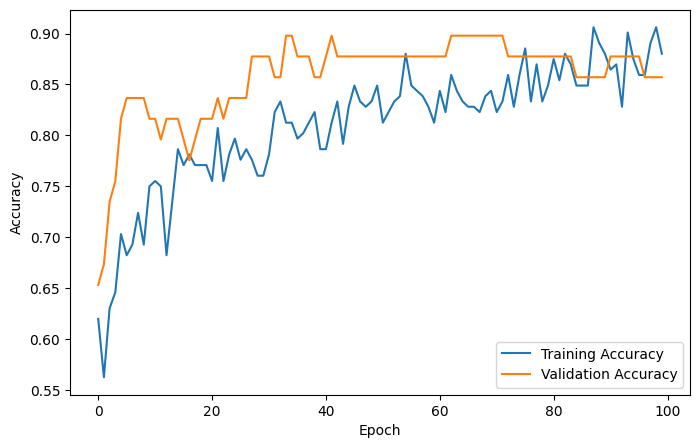

In [25]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [26]:
# Probability prediction

y_prob = ann_model.predict(
    X_test_processed
)


# Convert probability to class

y_pred = (y_prob >= 0.5).astype(int)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step


In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)


print(
    classification_report(
        y_test,
        y_pred
    )
)


print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred
    )
)


print(
    "Precision:",
    precision_score(
        y_test,
        y_pred
    )
)


print(
    "Recall:",
    recall_score(
        y_test,
        y_pred
    )
)


print(
    "F1 Score:",
    f1_score(
        y_test,
        y_pred
    )
)


print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        y_prob
    )
)

              precision    recall  f1-score   support

           0       0.81      0.79      0.80        28
           1       0.82      0.85      0.84        33

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61

Accuracy: 0.819672131147541
Precision: 0.8235294117647058
Recall: 0.8484848484848485
F1 Score: 0.835820895522388
ROC-AUC: 0.8766233766233766


In [28]:
naive_pipeline = Pipeline([
    ("preprocessor",preprocessor),
    ("model",GaussianNB())
])

In [29]:
naive_param={
"model__var_smoothing" : [
    1e-12,1e-5,1e-10
]    
}

In [30]:
from sklearn.model_selection import GridSearchCV
grid_search_naive = GridSearchCV(
    estimator=naive_pipeline,
    param_grid=naive_param,
    cv=5,
    scoring='f1', 
    n_jobs=-1
)

In [31]:
grid_search_naive.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         StandardScaler(),
                                                                         ['age',
                                                                          'trestbps',
                                                                          'chol',
                                                                          'thalach',
                                                                          'oldpeak']),
                                                                        ('categorical',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         ['sex',
                                                                          'cp',
                                                                          'fbs',
                                                                          'restecg',
                                                                          'exang',
                                                                          'slope',
                                                                          'ca',
                                                                          'thal'])])),
                                       ('model', GaussianNB())]),
             n_jobs=-1,
             param_grid={'model__var_smoothing': [1e-12, 1e-05, 1e-10]},
             scoring='f1')

In [32]:
grid_search_naive.best_estimator_

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical', StandardScaler(),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak']),
                                                 ('categorical',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['sex', 'cp', 'fbs',
                                                   'restecg', 'exang', 'slope',
                                                   'ca', 'thal'])])),
                ('model', GaussianNB(var_smoothing=1e-05))])

In [33]:
best_nb = grid_search_naive.best_estimator_

# Predictions
y_pred_naive = best_nb.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_naive))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_naive)
print(cm)

# TN, FP, FN, TP
tn, fp, fn, tp = cm.ravel()

print("False Negatives:", fn)
print("False Positives:", fp)
print("True Positives:", tp)
print("True Negatives:", tn)
print("Recall",(tp/(tp+fn)))

Accuracy: 0.8524590163934426
[[23  5]
 [ 4 29]]
False Negatives: 4
False Positives: 5
True Positives: 29
True Negatives: 23
Recall 0.8787878787878788


In [34]:
log_pipeline = Pipeline([
    ("preprocessor",preprocessor),
    ("model",LogisticRegression())
])

In [35]:
rf_pipeline = Pipeline([
    ("preprocessor",preprocessor),
    ("model",RandomForestClassifier())
])

In [36]:
ada_pipeline = Pipeline([
    ("preprocessor",preprocessor),
    ("model",AdaBoostClassifier())
])

In [37]:
# Logistic Regression Hyperparameters

log_reg_params = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs", "liblinear"],
    "model__class_weight": [None, "balanced"],
    "model__max_iter": [1000]
}


# Random Forest Hyperparameters

rf_params = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 3, 5, 7, 10],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5],
    "model__max_features": ["sqrt", "log2"],
    "model__class_weight": [None, "balanced"]
}


# AdaBoost Hyperparameters

ada_params = {
    "model__n_estimators": [50, 100, 200, 300],
    "model__learning_rate": [0.001, 0.01, 0.1, 0.5, 1],
    "model__algorithm": ["SAMME"]
}

In [38]:
grid_search_log = GridSearchCV(
    estimator=log_pipeline,
    param_grid=log_reg_params,
    cv=5,
    scoring='f1', 
    n_jobs=-1
)

In [39]:

grid_search_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_params,
    cv=5,
    scoring='f1', 
    n_jobs=-1
)

In [40]:
grid_search_ada = GridSearchCV(
    estimator=ada_pipeline,
    param_grid=ada_params,
    cv=5,
    scoring='f1', 
    n_jobs=-1
)

In [41]:
grid_search_log.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         StandardScaler(),
                                                                         ['age',
                                                                          'trestbps',
                                                                          'chol',
                                                                          'thalach',
                                                                          'oldpeak']),
                                                                        ('categorical',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         ['sex',
                                                                          'cp',
                                                                          'fbs',
                                                                          'restecg',
                                                                          'exang',
                                                                          'slope',
                                                                          'ca',
                                                                          'thal'])])),
                                       ('model', LogisticRegression())]),
             n_jobs=-1,
             param_grid={'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'model__class_weight': [None, 'balanced'],
                         'model__max_iter': [1000], 'model__penalty': ['l2'],
                         'model__solver': ['lbfgs', 'liblinear']},
             scoring='f1')

In [42]:
grid_search_rf.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         StandardScaler(),
                                                                         ['age',
                                                                          'trestbps',
                                                                          'chol',
                                                                          'thalach',
                                                                          'oldpeak']),
                                                                        ('categorical',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         ['sex',
                                                                          'cp',
                                                                          'fbs',
                                                                          'restecg',
                                                                          'exang',
                                                                          'slope',
                                                                          'ca',
                                                                          'thal'])])),
                                       ('model', RandomForestClassifier())]),
             n_jobs=-1,
             param_grid={'model__class_weight': [None, 'balanced'],
                         'model__max_depth': [None, 3, 5, 7, 10],
                         'model__max_features': ['sqrt', 'log2'],
                         'model__min_samples_leaf': [1, 2, 5],
                         'model__min_samples_split': [2, 5, 10],
                         'model__n_estimators': [100, 200, 300, 500]},
             scoring='f1')

In [43]:
grid_search_ada.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         StandardScaler(),
                                                                         ['age',
                                                                          'trestbps',
                                                                          'chol',
                                                                          'thalach',
                                                                          'oldpeak']),
                                                                        ('categorical',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         ['sex',
                                                                          'cp',
                                                                          'fbs',
                                                                          'restecg',
                                                                          'exang',
                                                                          'slope',
                                                                          'ca',
                                                                          'thal'])])),
                                       ('model', AdaBoostClassifier())]),
             n_jobs=-1,
             param_grid={'model__algorithm': ['SAMME'],
                         'model__learning_rate': [0.001, 0.01, 0.1, 0.5, 1],
                         'model__n_estimators': [50, 100, 200, 300]},
             scoring='f1')

In [44]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix


def evaluate_model(model, X_test, y_test):
    
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    
    print("Accuracy :", accuracy)
    print("Recall   :", recall)
    print("Precision:", precision)
    print("F1 Score :", f1)
    print("ROC-AUC  :", roc_auc)
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


# Example usage

evaluate_model(
    grid_search_rf.best_estimator_,
    X_test,
    y_test
)

Accuracy : 0.819672131147541
Recall   : 0.7878787878787878
Precision: 0.8666666666666667
F1 Score : 0.8253968253968254
ROC-AUC  : 0.895021645021645

Confusion Matrix:
[[24  4]
 [ 7 26]]


In [45]:
print("Naive Bayes")
best_nb = grid_search_naive.best_estimator_

# Predictions
y_pred_naive = best_nb.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_naive))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_naive)
print(cm)

# TN, FP, FN, TP
tn, fp, fn, tp = cm.ravel()

print("False Negatives:", fn)
print("False Positives:", fp)
print("True Positives:", tp)
print("True Negatives:", tn)
print("Recall",(tp/(tp+fn)))
print("Logistics Regression")
evaluate_model(grid_search_log.best_estimator_, X_test, y_test)
print("Random Forest")

evaluate_model(grid_search_rf.best_estimator_, X_test, y_test)
print("Adaboost")

evaluate_model(grid_search_ada.best_estimator_, X_test, y_test)

Naive Bayes
Accuracy: 0.8524590163934426
[[23  5]
 [ 4 29]]
False Negatives: 4
False Positives: 5
True Positives: 29
True Negatives: 23
Recall 0.8787878787878788
Logistics Regression
Accuracy : 0.8524590163934426
Recall   : 0.8484848484848485
Precision: 0.875
F1 Score : 0.8615384615384616
ROC-AUC  : 0.9058441558441559

Confusion Matrix:
[[24  4]
 [ 5 28]]
Random Forest
Accuracy : 0.819672131147541
Recall   : 0.7878787878787878
Precision: 0.8666666666666667
F1 Score : 0.8253968253968254
ROC-AUC  : 0.895021645021645

Confusion Matrix:
[[24  4]
 [ 7 26]]
Adaboost
Accuracy : 0.8032786885245902
Recall   : 0.7878787878787878
Precision: 0.8387096774193549
F1 Score : 0.8125
ROC-AUC  : 0.8874458874458875

Confusion Matrix:
[[23  5]
 [ 7 26]]
